In [ ]:
import pandas as pd
import numpy as np

# Mount Google Drive (if running in Google Colab)
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/NYA/superstore_final_dataset_new.csv"

# Read the CSV file using 'latin-1' encoding
ss = pd.read_csv(path, encoding='latin-1')
ss.head()

Mounted at /content/drive


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [ ]:
ss.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,443
Ship_Mode,2243
Customer_ID,0
Customer_Name,20
Segment,1326
Country,798
City,1683


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9357 non-null   object 
 4   Ship_Mode      7557 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9780 non-null   object 
 7   Segment        8474 non-null   object 
 8   Country        9002 non-null   object 
 9   City           8117 non-null   object 
 10  State          8038 non-null   object 
 11  Postal_Code    9580 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9678 non-null   object 
 16  Product_Name   9693 non-null   object 
 17  Sales          9610 non-null   float64
dtypes: float

**Cleaning and Transformation of the Data:**

**Checking for Duplicates**

In [ ]:
# Check for duplicates
duplicates = ss[ss.duplicated()]

# Count the number of duplicates
num_duplicates = duplicates.shape[0]

# Display the results
if num_duplicates > 0:
    print(f"Number of duplicate rows: {num_duplicates}")
    print("\nDuplicate Rows:")
    print(duplicates)
else:
    print("No duplicates found.")

No duplicates found.


Converting Data Types

In [ ]:
ss['Order_Date']=pd.to_datetime(ss['Order_Date'],format='%d/%m/%Y')
ss['Ship_Date']=pd.to_datetime(ss['Ship_Date'],format='%d/%m/%Y')
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9800 non-null   int64         
 1   Order_ID       9800 non-null   object        
 2   Order_Date     9800 non-null   datetime64[ns]
 3   Ship_Date      9357 non-null   datetime64[ns]
 4   Ship_Mode      7557 non-null   object        
 5   Customer_ID    9800 non-null   object        
 6   Customer_Name  9780 non-null   object        
 7   Segment        8474 non-null   object        
 8   Country        9002 non-null   object        
 9   City           8117 non-null   object        
 10  State          8038 non-null   object        
 11  Postal_Code    9580 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product_ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub_Category   9678 n

Creating New Columns

In [ ]:
ss['Days_Difference'] = (ss['Ship_Date'] - ss['Order_Date']).dt.days
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9800 non-null   int64         
 1   Order_ID         9800 non-null   object        
 2   Order_Date       9800 non-null   datetime64[ns]
 3   Ship_Date        9357 non-null   datetime64[ns]
 4   Ship_Mode        7557 non-null   object        
 5   Customer_ID      9800 non-null   object        
 6   Customer_Name    9780 non-null   object        
 7   Segment          8474 non-null   object        
 8   Country          9002 non-null   object        
 9   City             8117 non-null   object        
 10  State            8038 non-null   object        
 11  Postal_Code      9580 non-null   float64       
 12  Region           9800 non-null   object        
 13  Product_ID       9800 non-null   object        
 14  Category         9800 non-null   object 

Postal codes should be in Int after imputation

**Exploratory Analysis**

Data Overview

In [ ]:
# Check the shape of the dataset
print(f"Shape of the dataset: {ss.shape}")

# Check data types and non-null counts
print(ss.info())

Shape of the dataset: (9800, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9800 non-null   int64         
 1   Order_ID         9800 non-null   object        
 2   Order_Date       9800 non-null   datetime64[ns]
 3   Ship_Date        9357 non-null   datetime64[ns]
 4   Ship_Mode        7557 non-null   object        
 5   Customer_ID      9800 non-null   object        
 6   Customer_Name    9780 non-null   object        
 7   Segment          8474 non-null   object        
 8   Country          9002 non-null   object        
 9   City             8117 non-null   object        
 10  State            8038 non-null   object        
 11  Postal_Code      9580 non-null   float64       
 12  Region           9800 non-null   object        
 13  Product_ID       9800 non-null   object        
 14  Categor

Descriptive Statistics

In [ ]:
# Summary statistics for numerical columns
ss.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales,Days_Difference
count,9800.000000,9800,9357,9580.000000,9610.000000,9357.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 05:07:19.756332288,55307.183820,230.373460,4.146094
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,0.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-26 00:00:00,23223.000000,17.140000,3.000000
50%,4900.500000,2017-06-26 00:00:00,2017-07-02 00:00:00,58103.000000,54.088000,4.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-20 00:00:00,90008.000000,209.976750,5.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,7.000000
std,2829.160653,NaN,NaN,32035.133805,625.309955,1.564192


In [ ]:

# Count unique values in categorical columns
unique_counts = {col: ss[col].nunique() for col in ss.select_dtypes(include='object').columns}
print("Unique value counts for categorical columns:\n", unique_counts)

Unique value counts for categorical columns:
 {'Order_ID': 4922, 'Ship_Mode': 4, 'Customer_ID': 793, 'Customer_Name': 793, 'Segment': 3, 'Country': 1, 'City': 507, 'State': 49, 'Region': 4, 'Product_ID': 1861, 'Category': 3, 'Sub_Category': 17, 'Product_Name': 1849}


Missing Values Analysis

In [ ]:
# Calculate the overall percentage of null values
total_nulls = ss.isnull().sum().sum()  # Total number of nulls in the DataFrame
total_values = ss.size  # Total number of values in the DataFrame
percentage_nulls = (total_nulls / total_values) * 100  # Calculate percentage

print(f'Overall percentage of null values: {percentage_nulls:.2f}%')

Overall percentage of null values: 5.03%


Distribution Analysis

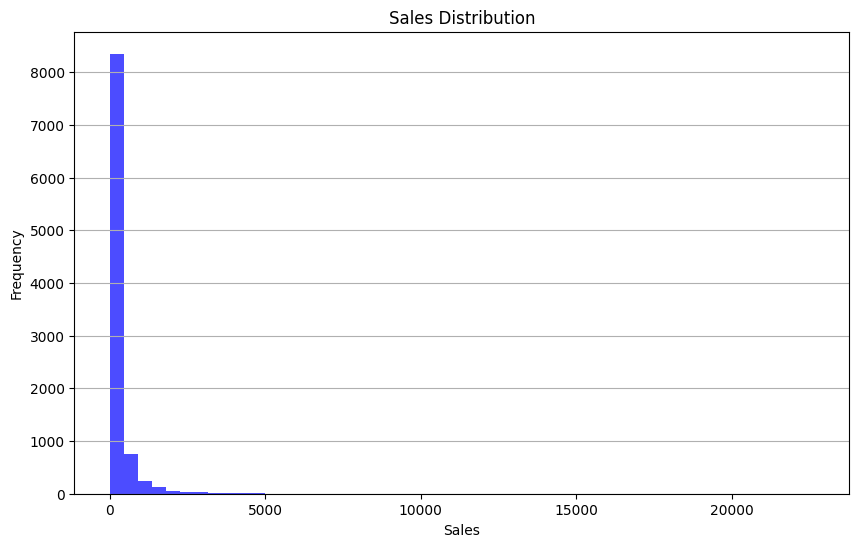

In [ ]:
#Sales Distribution

import matplotlib.pyplot as plt  # Import the matplotlib library
plt.figure(figsize=(10, 6))
plt.hist(ss['Sales'].dropna(), bins=50, alpha=0.7, color='blue')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

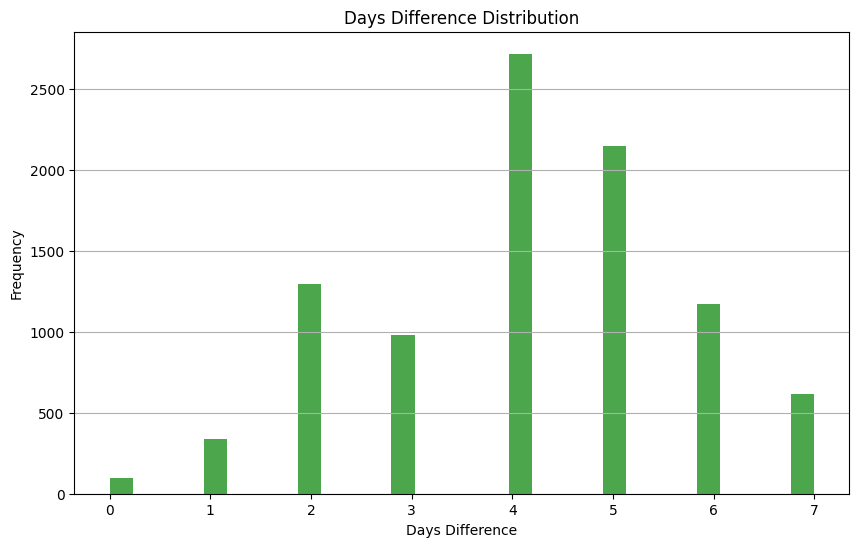

In [ ]:
#Days Difference Distribution

plt.figure(figsize=(10, 6))
plt.hist(ss['Days_Difference'].dropna(), bins=30, alpha=0.7, color='green')
plt.title('Days Difference Distribution')
plt.xlabel('Days Difference')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

Categorical Analysis

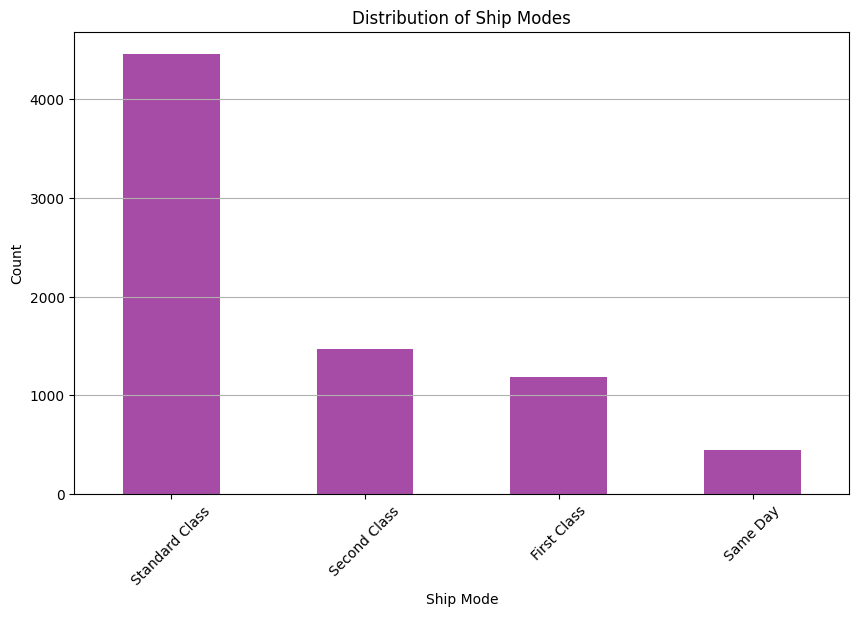

In [ ]:
#Ship Mode Analysis

plt.figure(figsize=(10, 6))
ss['Ship_Mode'].value_counts().plot(kind='bar', color='purple', alpha=0.7)
plt.title('Distribution of Ship Modes')
plt.xlabel('Ship Mode')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

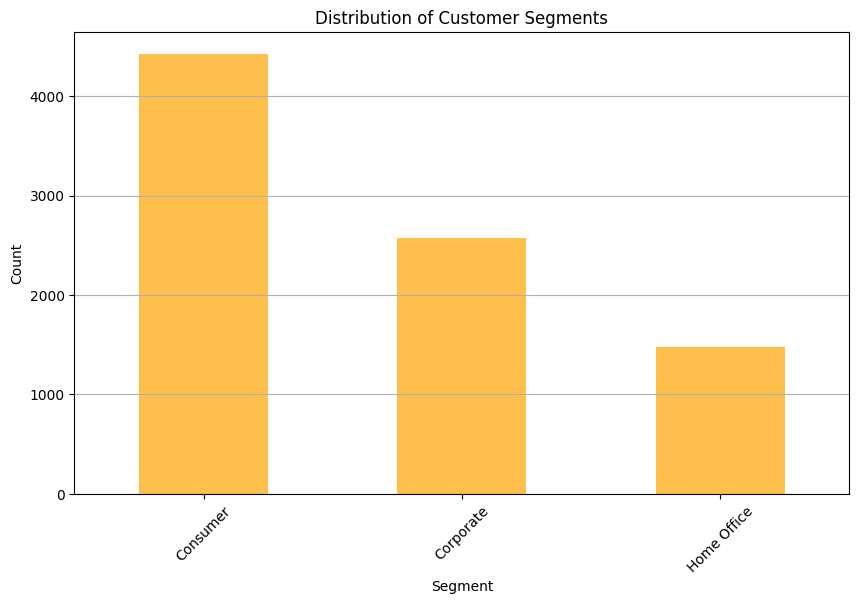

In [ ]:
#Customer Segment Analysis

plt.figure(figsize=(10, 6))
ss['Segment'].value_counts().plot(kind='bar', color='orange', alpha=0.7)
plt.title('Distribution of Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

**Imputing missing values**

**Ship_Date and Day_Difference columns Imputation:**

In [ ]:
ss['Ship_Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day', nan],
      dtype=object)

In [ ]:
average_days = ss.groupby('Ship_Mode')['Days_Difference'].mean().reset_index()
average_days

,Ship_Mode,Days_Difference
0,First Class,2.163437
1,Same Day,NaN
2,Second Class,3.250170
3,Standard Class,5.010987


In [ ]:
average_days = ss.groupby('Ship_Mode')['Days_Difference'].mean().reset_index()
first_class_avg_days = int(average_days.loc[average_days['Ship_Mode'] == 'First Class', 'Days_Difference'].values[0])
second_class_avg_days = int(average_days.loc[average_days['Ship_Mode'] == 'Second Class', 'Days_Difference'].values[0])
standard_class_avg_days = int(average_days.loc[average_days['Ship_Mode'] == 'Standard Class', 'Days_Difference'].values[0])

In [ ]:
print(first_class_avg_days)
print(second_class_avg_days)
print(standard_class_avg_days)

2
3
5


In [ ]:
# Finding the average number of days based on Ship_Mode
ss['Days_Difference'] = (ss['Ship_Date'] - ss['Order_Date']).dt.days
ss['Days_Difference'].fillna(ss['Days_Difference'].mean(), inplace=True)
ss['Days_Difference'] = ss['Days_Difference'].astype(int) # Changed line: Convert each element to int
average_days = ss.groupby('Ship_Mode')['Days_Difference'].mean().reset_index()
first_class_avg_days = int(average_days.loc[average_days['Ship_Mode'] == 'First Class', 'Days_Difference'].values[0])
second_class_avg_days = int(average_days.loc[average_days['Ship_Mode'] == 'Second Class', 'Days_Difference'].values[0])
standard_class_avg_days = int(average_days.loc[average_days['Ship_Mode'] == 'Standard Class', 'Days_Difference'].values[0])

# Define a function to calculate Ship_Date based on Ship_Mode
def calculate_ship_date(row):
    if pd.notnull(row['Ship_Date']):
        return row['Ship_Date']  # Return existing Ship_Date if available

    # Calculate Ship_Date based on Ship_Mode
    if row['Ship_Mode'] == 'Same Day':
        return row['Order_Date']  # Same day shipping
    elif row['Ship_Mode'] == 'First Class':
        return row['Order_Date'] + pd.Timedelta(days=first_class_avg_days)  # 2 day for First Class
    elif row['Ship_Mode'] == 'Standard Class':
        return row['Order_Date'] + pd.Timedelta(days=standard_class_avg_days)  # 5 days for Standard Class
    elif row['Ship_Mode'] == 'Second Class':
        return row['Order_Date'] + pd.Timedelta(days=second_class_avg_days)  # 3 days for Second Class
    else:
        return np.nan  # If no matching mode, return NaN

# Apply the function to the DataFrame
ss['Ship_Date'] = ss.apply(calculate_ship_date, axis=1)

# Display the updated DataFrame
ss.head()

<ipython-input-19-a4e851c3dab2>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ss['Days_Difference'].fillna(ss['Days_Difference'].mean(), inplace=True)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Days_Difference
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,7


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9800 non-null   int64         
 1   Order_ID         9800 non-null   object        
 2   Order_Date       9800 non-null   datetime64[ns]
 3   Ship_Date        9800 non-null   datetime64[ns]
 4   Ship_Mode        7557 non-null   object        
 5   Customer_ID      9800 non-null   object        
 6   Customer_Name    9780 non-null   object        
 7   Segment          8474 non-null   object        
 8   Country          9002 non-null   object        
 9   City             8117 non-null   object        
 10  State            8038 non-null   object        
 11  Postal_Code      9580 non-null   float64       
 12  Region           9800 non-null   object        
 13  Product_ID       9800 non-null   object        
 14  Category         9800 non-null   object 

**Ship_Mode column imputation:**


In [ ]:
ss['Days_Difference'].describe()

,Days_Difference
count,9800.000000
mean,4.139490
std,1.528727
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [ ]:
# Define a mapping function for Ship_Mode based on Days_Difference
def impute_ship_mode(days):
    if pd.isna(days):
        return None
    elif days == 0:
        return 'Same Day'
    elif days <= 2:
        return 'First Class'
    elif 3 <= days <= 5:
        return 'Standard Class'
    elif days > 5:
        return 'Second Class'
    return None

# Apply the function to fill missing Ship_Mode values based on Days_Difference
ss['Ship_Mode'] = ss['Ship_Mode'].combine_first(ss['Days_Difference'].apply(impute_ship_mode))

# Display the updated DataFrame
ss[['Row_ID', 'Order_ID', 'Ship_Mode', 'Days_Difference']]

,Row_ID,Order_ID,Ship_Mode,Days_Difference
0,1,CA-2017-152156,Second Class,3
1,2,CA-2017-152156,Second Class,3
2,3,CA-2017-138688,Second Class,4
3,4,US-2016-108966,Standard Class,7
4,5,US-2016-108966,Standard Class,7
...,...,...,...,...
9795,9796,CA-2017-125920,Standard Class,7
9796,9797,CA-2016-128608,Standard Class,5
9797,9798,CA-2016-128608,Standard Class,5
9798,9799,CA-2016-128608,Standard Class,5


In [ ]:
ss.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,20
Segment,1326
Country,798
City,1683


**Customer_Name Column imputation:**


In [ ]:
ss['Customer_ID'].nunique()

793

In [ ]:
# Group by Customer_ID and aggregate the most common Customer_Name
mode_customer_names = ss.groupby('Customer_ID')['Customer_Name'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

# Update the Customer_Name in the original DataFrame
ss['Customer_Name'] = ss['Customer_Name'].combine_first(ss['Customer_ID'].map(mode_customer_names))

# Display the updated DataFrame
ss.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Days_Difference
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,7


In [ ]:
ss.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,1326
Country,798
City,1683


In [ ]:
ss['Customer_Name'].nunique()

793

**Segment column Imputation:**

In [ ]:
ss['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office', nan], dtype=object)

In [ ]:
# Group by Customer_Name and find the most common Segment
mode_segments = ss.groupby('Customer_Name')['Segment'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

# Map the most common segments back to the original DataFrame
ss['Segment'] = ss['Segment'].combine_first(ss['Customer_Name'].map(mode_segments))

# Optionally fill remaining NaNs with a predefined value or mode
ss['Segment'].fillna('Unknown', inplace=True)

# Display the updated DataFrame
ss.head()

<ipython-input-29-fded283b109e>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ss['Segment'].fillna('Unknown', inplace=True)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Days_Difference
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,7


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9800 non-null   int64         
 1   Order_ID         9800 non-null   object        
 2   Order_Date       9800 non-null   datetime64[ns]
 3   Ship_Date        9800 non-null   datetime64[ns]
 4   Ship_Mode        9800 non-null   object        
 5   Customer_ID      9800 non-null   object        
 6   Customer_Name    9800 non-null   object        
 7   Segment          9800 non-null   object        
 8   Country          9002 non-null   object        
 9   City             8117 non-null   object        
 10  State            8038 non-null   object        
 11  Postal_Code      9580 non-null   float64       
 12  Region           9800 non-null   object        
 13  Product_ID       9800 non-null   object        
 14  Category         9800 non-null   object 

**Country Column Imputation:**

In [ ]:
ss['Country'].unique()

array(['United States', nan], dtype=object)

In [ ]:
#Filling the missing values in Country column with 'United States'.
ss['Country'].fillna('United States', inplace=True)


<ipython-input-32-fae0d369f103>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ss['Country'].fillna('United States', inplace=True)


In [ ]:
ss['Country'].unique()

array(['United States'], dtype=object)

In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9800 non-null   int64         
 1   Order_ID         9800 non-null   object        
 2   Order_Date       9800 non-null   datetime64[ns]
 3   Ship_Date        9800 non-null   datetime64[ns]
 4   Ship_Mode        9800 non-null   object        
 5   Customer_ID      9800 non-null   object        
 6   Customer_Name    9800 non-null   object        
 7   Segment          9800 non-null   object        
 8   Country          9800 non-null   object        
 9   City             8117 non-null   object        
 10  State            8038 non-null   object        
 11  Postal_Code      9580 non-null   float64       
 12  Region           9800 non-null   object        
 13  Product_ID       9800 non-null   object        
 14  Category         9800 non-null   object 

**Imputation of City Column**

In [ ]:
# finding postal codes for all the cities
ss_cities =ss[['City', 'Postal_Code']]
ss_cities.dropna(inplace = True)
ss_cities.drop_duplicates(inplace = True)
ss_cities.nunique()

<ipython-input-35-063c80c31aae>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss_cities.dropna(inplace = True)
<ipython-input-35-063c80c31aae>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss_cities.drop_duplicates(inplace = True)


,0
City,503
Postal_Code,600


In [ ]:
# mapping cities and postal codes
grouped_cities = ss_cities.groupby(['City', 'Postal_Code']).size().reset_index(name='Frequency')

city_dict = {}
for _, row in grouped_cities.iterrows():
    city = row['City']
    postal_code = row['Postal_Code']
    frequency = row['Frequency']

    if city not in city_dict:
        city_dict[city] = {}

    city_dict[city][postal_code] = frequency

In [ ]:
# finding city by postal codes
def find_city_by_postal_code(city_dict, postal_code):
    for city, postal_codes in city_dict.items():
        if postal_code in postal_codes:
            return city
    return None

# filling city values into the DataFrame
for i in range(len(ss)):
    if pd.isnull(ss['City'][i]):
        ss['City'][i] = find_city_by_postal_code(city_dict, ss['Postal_Code'][i])

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ss['City'][i] = find_city_by_postal_code(city_dict, ss['Postal_Code'][i])
<ipython-input-37-598d5d1be3a5>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss['City'][i] = find_city_by_postal_code(city_dict, ss['Postal_Code'][i])
<ipython-input-37-598d5d1be3a5>:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on whi

In [ ]:
ss['City'].isnull().sum()

84

In [ ]:
ss['City'].fillna('Unknown', inplace=True)

<ipython-input-39-51294bae5f54>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ss['City'].fillna('Unknown', inplace=True)


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9800 non-null   int64         
 1   Order_ID         9800 non-null   object        
 2   Order_Date       9800 non-null   datetime64[ns]
 3   Ship_Date        9800 non-null   datetime64[ns]
 4   Ship_Mode        9800 non-null   object        
 5   Customer_ID      9800 non-null   object        
 6   Customer_Name    9800 non-null   object        
 7   Segment          9800 non-null   object        
 8   Country          9800 non-null   object        
 9   City             9800 non-null   object        
 10  State            8038 non-null   object        
 11  Postal_Code      9580 non-null   float64       
 12  Region           9800 non-null   object        
 13  Product_ID       9800 non-null   object        
 14  Category         9800 non-null   object 

**Imputation of State Column**

In [ ]:
ss_states = ss[['State', 'Postal_Code']]
ss_states.dropna(inplace = True)
ss_states.drop_duplicates(inplace=True)
ss_states.isnull().sum()

<ipython-input-41-6eb15875ec24>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss_states.dropna(inplace = True)
<ipython-input-41-6eb15875ec24>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss_states.drop_duplicates(inplace=True)


,0
State,0
Postal_Code,0


In [ ]:
ss[ss['State'].isnull() & ss['Postal_Code'].isnull()].shape

(7, 19)

In [ ]:
# mapping states and postal codes
grouped_states = ss_states.groupby(['State', 'Postal_Code']).size().reset_index(name='Frequency')


state_dict = {}
for _, row in grouped_states.iterrows():
    state = row['State']
    postal_code = row['Postal_Code']
    frequency = row['Frequency']

    if state not in state_dict:
        state_dict[state] = {}

    state_dict[state][postal_code] = frequency

In [ ]:
# finding state by postal codes
def find_state_by_postal_code(state_dict, postal_code):
    for state, postal_codes in state_dict.items():
        if postal_code in postal_codes:
            return state
    return None

# filling state values into the DataFrame
for i in range(len(ss)):
    if type(ss['State'][i]) == float:
        ss['State'][i] = find_state_by_postal_code(state_dict, ss['Postal_Code'][i])

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ss['State'][i] = find_state_by_postal_code(state_dict, ss['Postal_Code'][i])
<ipython-input-44-eb8322dce4e6>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss['State'][i] = find_state_by_postal_code(state_dict, ss['Postal_Code'][i])
<ipython-input-44-eb8322dce4e6>:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object 

In [ ]:
ss['State'].isnull().sum()

66

In [ ]:
ss['State'].fillna('Unknown', inplace=True)

<ipython-input-46-fa44a2194c4c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ss['State'].fillna('Unknown', inplace=True)


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9800 non-null   int64         
 1   Order_ID         9800 non-null   object        
 2   Order_Date       9800 non-null   datetime64[ns]
 3   Ship_Date        9800 non-null   datetime64[ns]
 4   Ship_Mode        9800 non-null   object        
 5   Customer_ID      9800 non-null   object        
 6   Customer_Name    9800 non-null   object        
 7   Segment          9800 non-null   object        
 8   Country          9800 non-null   object        
 9   City             9800 non-null   object        
 10  State            9800 non-null   object        
 11  Postal_Code      9580 non-null   float64       
 12  Region           9800 non-null   object        
 13  Product_ID       9800 non-null   object        
 14  Category         9800 non-null   object 

**Imputation of Postal_Code Column**

In [ ]:
ss['Postal_Code'].isnull().sum()

220

In [ ]:
# Impute missing 'Postal_Code' based on 'City', 'State', and 'Region'
ss['Postal_Code'] = ss.groupby(['City', 'State', 'Region'])['Postal_Code'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

# Verify imputation by checking for missing values
print(ss['Postal_Code'].isnull().sum())  # Expected output: 0, if imputation was successful

0


In [ ]:
(ss['Postal_Code']=='Unknown').sum()

37

In [ ]:
# Drop rows where 'Postal_Code' is 'Unknown' or any placeholder value
ss = ss[ss['Postal_Code'] != 'Unknown']

# Verify the result by checking the shape of the DataFrame after dropping
print(ss.shape)  # Displays the new shape of the DataFrame after dropping rows

(9763, 19)


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9763 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9763 non-null   int64         
 1   Order_ID         9763 non-null   object        
 2   Order_Date       9763 non-null   datetime64[ns]
 3   Ship_Date        9763 non-null   datetime64[ns]
 4   Ship_Mode        9763 non-null   object        
 5   Customer_ID      9763 non-null   object        
 6   Customer_Name    9763 non-null   object        
 7   Segment          9763 non-null   object        
 8   Country          9763 non-null   object        
 9   City             9763 non-null   object        
 10  State            9763 non-null   object        
 11  Postal_Code      9763 non-null   object        
 12  Region           9763 non-null   object        
 13  Product_ID       9763 non-null   object        
 14  Category         9763 non-null   object      

**Imputation of Product_Name Column**

In [ ]:
ss['Product_Name'].nunique()

1846

In [ ]:
ss['Product_ID'].nunique()

1858

In [ ]:
# Assuming df is your DataFrame
# Fill missing 'Product_Name' based on 'Product_ID'
ss['Product_Name'] = ss.groupby('Product_ID')['Product_Name'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

<ipython-input-55-68d5b041a41c>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ss['Product_Name'] = ss.groupby('Product_ID')['Product_Name'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


In [ ]:
# Check the result
print(ss['Product_Name'].isnull().sum())  # Should be 0 if all missing values are imputed

0


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9763 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9763 non-null   int64         
 1   Order_ID         9763 non-null   object        
 2   Order_Date       9763 non-null   datetime64[ns]
 3   Ship_Date        9763 non-null   datetime64[ns]
 4   Ship_Mode        9763 non-null   object        
 5   Customer_ID      9763 non-null   object        
 6   Customer_Name    9763 non-null   object        
 7   Segment          9763 non-null   object        
 8   Country          9763 non-null   object        
 9   City             9763 non-null   object        
 10  State            9763 non-null   object        
 11  Postal_Code      9763 non-null   object        
 12  Region           9763 non-null   object        
 13  Product_ID       9763 non-null   object        
 14  Category         9763 non-null   object      

**Imputation of Sub_Category Column**

In [ ]:
ss['Sub_Category'].isnull().sum()

122

In [ ]:
# Impute missing 'Sub_Category' values based on 'Product_ID' and 'Category'
ss['Sub_Category'] = ss.groupby(['Product_ID', 'Category'])['Sub_Category'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

In [ ]:
ss['Sub_Category'].isnull().sum()

0

In [ ]:
(ss['Sub_Category']=='Unknown').sum()

1

**Imputation of Sales Column**

In [ ]:
ss['Sales'].isnull().sum()

190

In [ ]:
# finding mean of sales based on region,category and subcategory
mean_sales = ss.groupby(['Region', 'Category', 'Sub_Category'])['Sales'].mean().reset_index()
ss = pd.merge(ss, mean_sales, on=['Region', 'Category', 'Sub_Category'], suffixes=('', '_mean'))
ss['Sales'] = ss['Sales'].fillna(ss['Sales_mean'])
ss.drop("Sales_mean",axis=1,inplace=True)

In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9763 entries, 0 to 9762
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9763 non-null   int64         
 1   Order_ID         9763 non-null   object        
 2   Order_Date       9763 non-null   datetime64[ns]
 3   Ship_Date        9763 non-null   datetime64[ns]
 4   Ship_Mode        9763 non-null   object        
 5   Customer_ID      9763 non-null   object        
 6   Customer_Name    9763 non-null   object        
 7   Segment          9763 non-null   object        
 8   Country          9763 non-null   object        
 9   City             9763 non-null   object        
 10  State            9763 non-null   object        
 11  Postal_Code      9763 non-null   object        
 12  Region           9763 non-null   object        
 13  Product_ID       9763 non-null   object        
 14  Category         9763 non-null   object 

**Analysis of the Superstore:**

**5.1.	What are the trends in total sales over time (monthly, quarterly, annually)?**

Steps of Analysis


1.  Aggregate total sales over time for monthly, quarterly, and annual periods.
2.  Visualize the trends using matplotlib.
3.  Calculate Growth Rates: Calculate the percentage change in sales from month to month, quarter to quarter, and year to year.

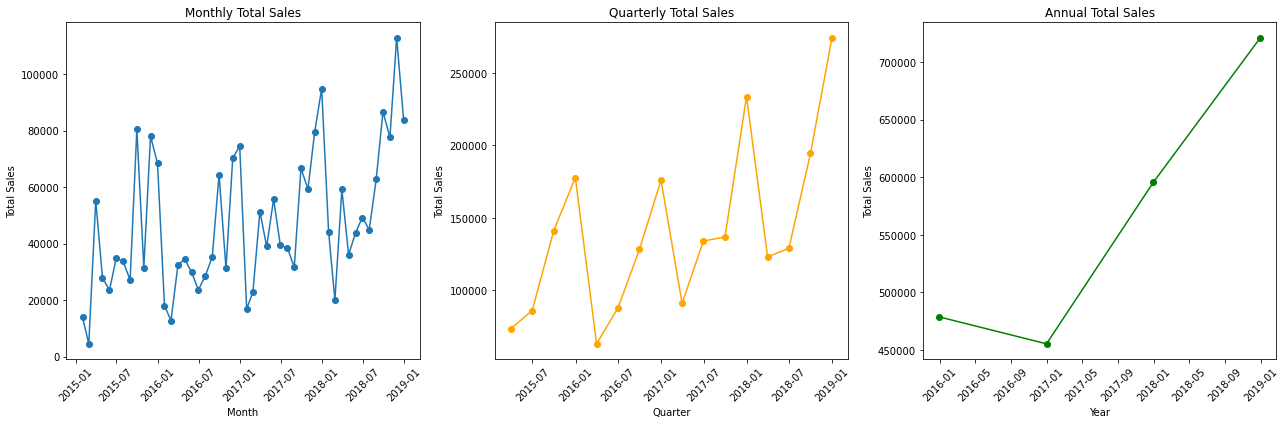

In [ ]:
import matplotlib.pyplot as plt

# Set the 'Order_Date' as the index
ss.set_index('Order_Date', inplace=True)

# Monthly Total Sales
monthly_sales = ss.resample('M')['Sales'].sum()

# Quarterly Total Sales
quarterly_sales = ss.resample('Q')['Sales'].sum()

# Annual Total Sales
annual_sales = ss.resample('A')['Sales'].sum()

# Plotting the trends
plt.figure(figsize=(18, 6))

# Monthly Sales
plt.subplot(1, 3, 1)
plt.plot(monthly_sales.index, monthly_sales, marker='o')
plt.title('Monthly Total Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

# Quarterly Sales
plt.subplot(1, 3, 2)
plt.plot(quarterly_sales.index, quarterly_sales, marker='o', color='orange')
plt.title('Quarterly Total Sales')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

# Annual Sales
plt.subplot(1, 3, 3)
plt.plot(annual_sales.index, annual_sales, marker='o', color='green')
plt.title('Annual Total Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Monthly Growth Rate
monthly_growth = monthly_sales.pct_change() * 100

# Quarterly Growth Rate
quarterly_growth = quarterly_sales.pct_change() * 100

# Annual Growth Rate
annual_growth = annual_sales.pct_change() * 100

print("Monthly Growth Rate:")
print(monthly_growth)

print("\nQuarterly Growth Rate:")
print(quarterly_growth)

print("\nAnnual Growth Rate:")
print(annual_growth)

Monthly Growth Rate:
Order_Date
2015-01-31            NaN
2015-02-28     -67.487653
2015-03-31    1121.396374
2015-04-30     -49.455695
2015-05-31     -15.799355
2015-06-30      48.028209
2015-07-31      -3.171550
2015-08-31     -19.475054
2015-09-30     196.462242
2015-10-31     -60.908852
2015-11-30     148.245009
2015-12-31     -12.369534
2016-01-31     -73.572789
2016-02-29     -29.606507
2016-03-31     154.972218
2016-04-30       6.410405
2016-05-31     -13.646273
2016-06-30     -20.800052
2016-07-31      21.224652
2016-08-31      23.522204
2016-09-30      82.240960
2016-10-31     -51.497009
2016-11-30     124.773203
2016-12-31       6.194254
2017-01-31     -77.373196
2017-02-28      35.694314
2017-03-31     124.333538
2017-04-30     -24.097024
2017-05-31      42.875579
2017-06-30     -29.237471
2017-07-31      -2.127317
2017-08-31     -18.012619
2017-09-30     110.763080
2017-10-31     -11.094029
2017-11-30      34.196930
2017-12-31      19.299734
2018-01-31     -53.503711
2018-0

**5.2.	Which product categories generate the highest revenue, and how do they compare to one another?**

Category
Technology         819273.390744
Furniture          723858.182854
Office Supplies    707801.761522
Name: Sales, dtype: float64


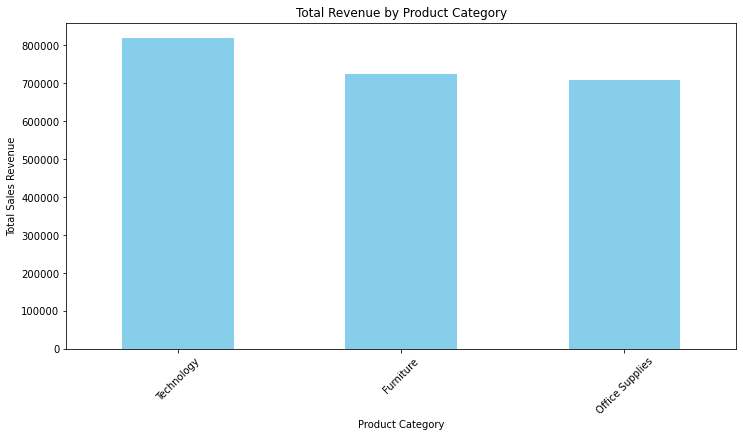

In [ ]:
# Group by Category and sum the sales
category_revenue = ss.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Display the revenue by category
print(category_revenue)

# Plotting the revenue by category
plt.figure(figsize=(12, 6))
category_revenue.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Revenue')
plt.xticks(rotation=45)
plt.show()

In [ ]:
total_revenue = ss['Sales'].sum()
category_percentage = (category_revenue / total_revenue) * 100
print(category_percentage)

Category
Technology         36.397053
Furniture          32.158135
Office Supplies    31.444812
Name: Sales, dtype: float64


**5.3.How do sales vary across different regions and cities, and what factors may influence these differences?**

Steps for Analysis


1.  Aggregate Sales by Region and City: Sum the total sales for each region and city.
2.  Visualize Sales Distribution: Use bar charts to visualize sales across regions and cities.
3.  Basic Comparison: Calculate and compare averages and total sales across regions and cities.
4. Understanding the Influencing Factors.


In [ ]:
# Total sales by region
sales_by_region = ss.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Total sales by city
sales_by_city = ss.groupby('City')['Sales'].sum().sort_values(ascending=False)

# Display results
print("Sales by Region:")
print(sales_by_region)
print("\nSales by City (Top 10):")
print(sales_by_city.head(10))  # Show top 10 cities

Sales by Region:
Region
West       710336.844814
East       662992.371727
Central    491795.539335
South      385808.579245
Name: Sales, dtype: float64

Sales by City (Top 10):
City
New York City    253331.263188
Los Angeles      174703.436249
Seattle          116746.159336
San Francisco    110168.811899
Philadelphia     109438.314297
Houston           62083.030900
Chicago           48074.323923
Jacksonville      45235.964138
San Diego         44511.418953
Springfield       41827.810000
Name: Sales, dtype: float64


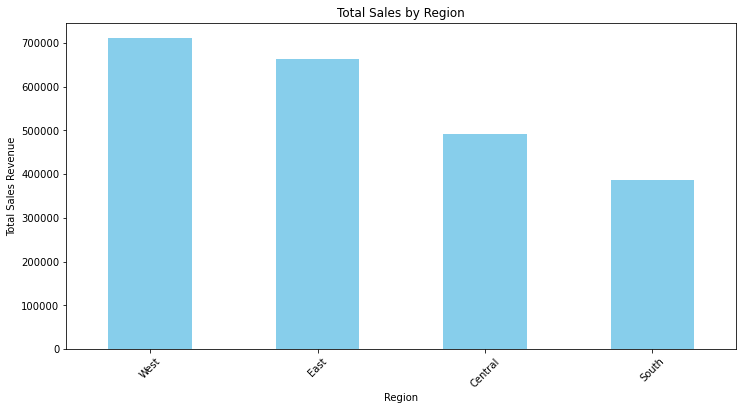

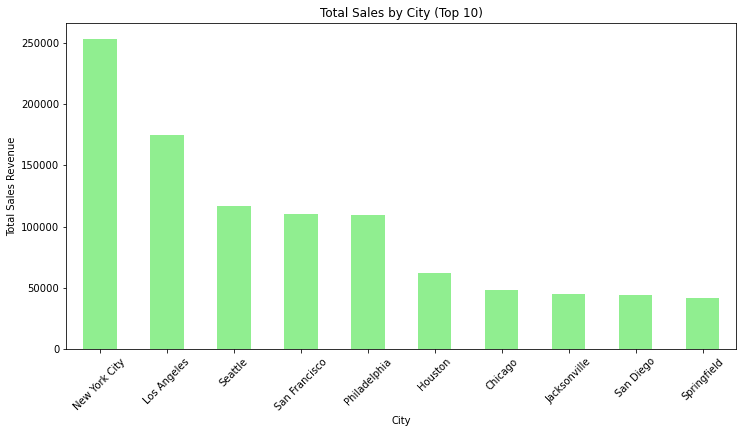

In [ ]:
# Plotting sales by region
plt.figure(figsize=(12, 6))
sales_by_region.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales Revenue')
plt.xticks(rotation=45)
plt.show()

# Plotting sales by city (top 10)
plt.figure(figsize=(12, 6))
sales_by_city.head(10).plot(kind='bar', color='lightgreen')
plt.title('Total Sales by City (Top 10)')
plt.xlabel('City')
plt.ylabel('Total Sales Revenue')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Average sales by region
average_sales_by_region = ss.groupby('Region')['Sales'].mean()
print("\nAverage Sales by Region:")
print(average_sales_by_region)

# Average sales by city
average_sales_by_city = ss.groupby('City')['Sales'].mean()
print("\nAverage Sales by City (Top 10):")
print(average_sales_by_city.sort_values(ascending=False).head(10))  # Show top 10 cities


Average Sales by Region:
Region
Central    215.983987
East       239.002297
South      241.432152
West       226.221925
Name: Sales, dtype: float64

Average Sales by City (Top 10):
City
Jamestown       2354.395000
Cheyenne        1603.136000
Bellingham      1263.413333
Independence    1208.685000
Burbank         1082.386000
Buffalo          906.349600
Beverly          861.063333
Lafayette        860.147586
Sparks           853.986667
Appleton         835.655000
Name: Sales, dtype: float64


In [ ]:
# Correlation with Days taken to ship from the order received
avg_days_by_region = ss.groupby('Region')['Days_Difference'].mean()
print("\nAverage Days Difference by Region:")
print(avg_days_by_region)

# Combining average sales and days difference for comparison
comparison_df = pd.DataFrame({
    'Average Sales': average_sales_by_region,
    'Average Days Difference': avg_days_by_region
})

print("\nComparison of Average Sales and Days Difference by Region:")
print(comparison_df)


Average Days Difference by Region:
Region
Central    4.065876
East       3.910238
South      3.961202
West       3.930255
Name: Days_Difference, dtype: float64

Comparison of Average Sales and Days Difference by Region:
         Average Sales  Average Days Difference
Region                                         
Central     215.983987                 4.065876
East        239.002297                 3.910238
South       241.432152                 3.961202
West        226.221925                 3.930255


In [ ]:
gb=ss.groupby('Region')['Days_Difference']
gb.describe()

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
Central,2277.0,4.065876,1.686569,0.0,3.0,4.0,5.0,7.0
East,2774.0,3.910238,1.732222,0.0,3.0,4.0,5.0,7.0
South,1598.0,3.961202,1.742610,0.0,3.0,4.0,5.0,7.0
West,3140.0,3.930255,1.812467,0.0,3.0,4.0,5.0,7.0


In [ ]:
# Select only numeric columns for correlation calculation
numerical_cols = ss.select_dtypes(include=np.number).columns
correlation = ss[numerical_cols].corr()['Sales'].sort_values(ascending=False)
print("Correlation with Sales:")
print(correlation)

# You can also group by region or city to check the average Days_Difference
avg_days_by_region = ss.groupby('Region')['Days_Difference'].mean()
print("\nAverage Days Difference by Region:")
print(avg_days_by_region)

Correlation with Sales:
Sales              1.000000
Row_ID             0.000035
Days_Difference   -0.004050
Name: Sales, dtype: float64

Average Days Difference by Region:
Region
Central    4.065876
East       3.910238
South      3.961202
West       3.930255
Name: Days_Difference, dtype: float64


**Notes:**
Days_Difference (-0.007272):

The correlation between Sales and Days_Difference is also close to zero (-0.0072). This indicates that there is almost no linear relationship between the number of days difference and sales. This means that variations in shipping time do not seem to significantly affect sales in this dataset.

Average Days Difference by Region
The average days difference by region provides insights into shipping times across different areas:

Central (4.24 days)
East (4.09 days)
South (4.13 days)
West (4.11 days)
Interpretation of Average Days Difference
The average days difference in shipping times is relatively consistent across regions, with the Central region taking slightly longer on average.
Since the average shipping times do not differ significantly, it may indicate that shipping logistics are relatively uniform across regions.
Overall Insights
Sales and Days Difference: The very low correlation indicates that shipping time does not significantly impact sales in your dataset. This could suggest that customers are not deterred by shipping times or that other factors are more influential.

**5.4.	What is the relationship between customer segments and their purchasing behavior (average order value, frequency of purchases)?**

Steps for Analysis
1. Data Preparation: Ensuring the dataset has the necessary columns, particularly Customer_ID, Segment, Sales, and the frequency of purchases (which can be derived from the order count per customer).

2. Calculate Average Order Value (AOV):AOV can be calculated as total sales divided by the number of orders for each segment.

3. Calculate Purchase Frequency: Count the number of purchases for each customer and then aggregate this by segment to find the average frequency.

4. Visualization: Use bar charts or box plots to visualize the average order value and purchase frequency by customer segment.

In [ ]:
# Calculate total sales and order count per customer
customer_data = ss.groupby('Customer_ID').agg({
    'Sales': 'sum',
    'Order_ID': 'count'
}).reset_index()

# Rename columns for clarity
customer_data.rename(columns={'Sales': 'Total_Sales', 'Order_ID': 'Purchase_Count'}, inplace=True)
# Sort customer_data by Order Count in descending order
customer_data_sorted = customer_data.sort_values(by='Purchase_Count', ascending=False).reset_index()

# Display the sorted customer_data
print(customer_data_sorted)

     index Customer_ID  Total_Sales  Purchase_Count
0      787    WB-21850  6129.710000              35
1      482    MA-17560  4299.161000              34
2      606    PP-18955  7252.608000              34
3      387    JL-15835  9527.001241              33
4      147    CK-12205  3154.855000              32
..     ...         ...          ...             ...
788     42    AO-10810   161.280000               1
789    681    SC-20845    14.112000               1
790    456    LD-16855     5.304000               1
791    403    JR-15700   863.880000               1
792    637    RE-19405    48.360000               1

[793 rows x 4 columns]


In [ ]:
# Merge back with segments
customer_segments = ss[['Customer_ID', 'Segment']].drop_duplicates()
merged_data = pd.merge(customer_data, customer_segments, on='Customer_ID')
merged_data

,Customer_ID,Total_Sales,Purchase_Count,Segment
0,AA-10315,5563.560000,11,Consumer
1,AA-10375,1056.390000,15,Consumer
2,AA-10480,1790.512000,12,Consumer
3,AA-10645,5086.935000,18,Consumer
4,AB-10015,886.156000,6,Consumer
...,...,...,...,...
788,XP-21865,2374.658000,28,Consumer
789,YC-21895,6364.342857,8,Corporate
790,YS-21880,6720.444000,12,Corporate
791,ZC-21910,8025.707000,31,Consumer


In [ ]:
# Calculate Average Order Value (AOV) and Purchase Frequency
segment_analysis = merged_data.groupby('Segment').agg({'Total_Sales': 'sum', 'Purchase_Count': 'mean'}).reset_index()
segment_analysis

,Segment,Total_Sales,Purchase_Count
0,Consumer,1.149505e+06,12.459658
1,Corporate,6.771433e+05,12.491525
2,Home Office,4.242848e+05,11.790541


In [ ]:
segment_analysis['Average_Order_Value'] = segment_analysis['Total_Sales'] / segment_analysis['Purchase_Count']
# Display results
print(segment_analysis[['Segment', 'Average_Order_Value', 'Purchase_Count']])

       Segment  Average_Order_Value  Purchase_Count
0     Consumer         92258.174936       12.459658
1    Corporate         54208.214403       12.491525
2  Home Office         35985.183663       11.790541


In [ ]:
# Display results
print(segment_analysis[['Segment', 'Average_Order_Value', 'Purchase_Count']])

       Segment  Average_Order_Value  Purchase_Count
0     Consumer         92258.174936       12.459658
1    Corporate         54208.214403       12.491525
2  Home Office         35985.183663       11.790541


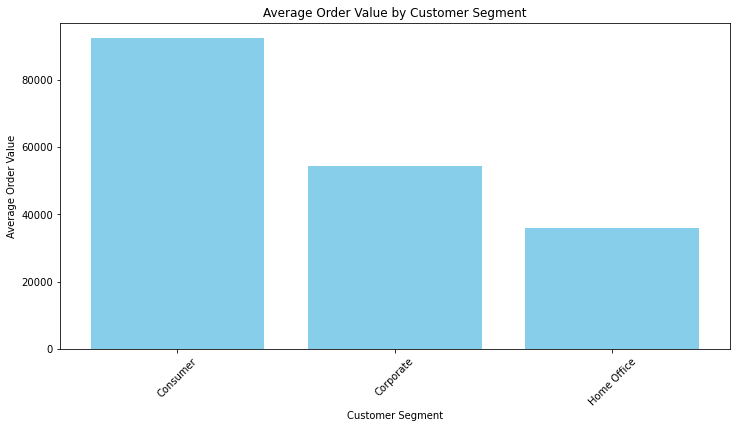

In [ ]:
#Average Order Value by Segment
plt.figure(figsize=(12, 6))
plt.bar(segment_analysis['Segment'], segment_analysis['Average_Order_Value'], color='skyblue')
plt.title('Average Order Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.show()

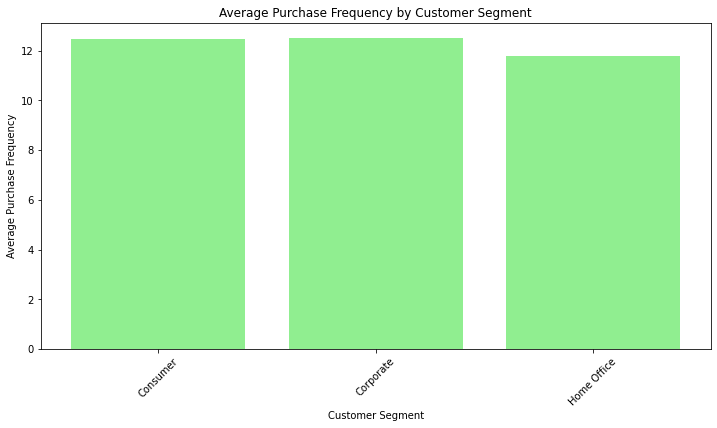

In [ ]:
#Purchase Frequency by Segment
plt.figure(figsize=(12, 6))
plt.bar(segment_analysis['Segment'], segment_analysis['Purchase_Count'], color='lightgreen')
plt.title('Average Purchase Frequency by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Purchase Frequency')
plt.xticks(rotation=45)
plt.show()

**Notes:**
Interpreting the Results
Average Order Value:

Higher AOV in a particular segment suggests that customers in that segment are willing to spend more per order. This could indicate a preference for premium products or effective marketing strategies.
Purchase Frequency:

A higher average purchase frequency indicates that customers in that segment are more loyal or more engaged. This might be due to targeted promotions or tailored marketing efforts.
Comparative Insights:

Comparing AOV and purchase frequency across segments helps identify which segments are most profitable and engaged.
Segments with high frequency but low AOV may benefit from strategies aimed at upselling or cross-selling.
Reccomendation: Customer Feedback: Gather qualitative data on customer preferences to understand motivations behind purchasing behaviors.

**Recommendations**:

Upselling & Cross-selling: Target segments like Home Office and Unknown, which show lower AOV, with strategies aimed at increasing average order values.
Loyalty Programs: For high-frequency segments like Consumer and Corporate, loyalty programs or repeat purchase incentives could further increase engagement and sales.
Customer Feedback: Gathering qualitative insights from customers could help understand the reasons behind the differences in AOV and purchase frequency, allowing for more personalized marketing approaches.

**5.5.	Are there specific times of the year when sales peak, and how can this information be used for inventory management?**

Steps for Analysis

1. Extract Time Features: Create new columns for the month and year from the Order_Date to facilitate time-based analysis.

2. Aggregate Sales Data: Group the data by month and year to find total sales for each month.

3. Identify Peaks: Determine which months have the highest sales.

4. Make Recommendations for Inventory Management: Based on the analysis, provide insights on how to manage inventory.

5. Visualize the Sales Trends: Use a plot to visualize the sales data over time.


In [ ]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9789 entries, 2017-11-08 to 2018-11-03
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row_ID           9789 non-null   int64         
 1   Order_ID         9789 non-null   object        
 2   Ship_Date        9789 non-null   datetime64[ns]
 3   Ship_Mode        9789 non-null   object        
 4   Customer_ID      9789 non-null   object        
 5   Customer_Name    9789 non-null   object        
 6   Segment          9789 non-null   object        
 7   Country          9789 non-null   object        
 8   City             9789 non-null   object        
 9   State            9789 non-null   object        
 10  Postal_Code      9789 non-null   object        
 11  Region           9789 non-null   object        
 12  Product_ID       9789 non-null   object        
 13  Category         9789 non-null   object        
 14  Sub_Category     9789 

In [ ]:
ss.reset_index(inplace=True)

In [ ]:
# Extract time features
ss['Year'] = ss['Order_Date'].dt.year
ss['Month'] = ss['Order_Date'].dt.month

# Aggregate sales data by month and year
monthly_sales = ss.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales

,Year,Month,Sales
0,2015,1,13902.078358
1,2015,2,4519.892000
2,2015,3,55205.797000
3,2015,4,27903.386150
4,2015,5,23494.831062
5,2015,6,34778.977569
6,2015,7,33675.944985
7,2015,8,27117.536500
8,2015,9,80393.256548
9,2015,10,31426.646993


In [ ]:
peak_sales = monthly_sales.loc[monthly_sales.groupby('Year')['Sales'].idxmax()]
peak_sales

,Year,Month,Sales
8,2015,9,80393.256548
23,2016,12,74558.392224
35,2017,12,94866.260648
46,2018,11,112871.817980


In [ ]:
# Determine which months require high inventory management
# Assuming months with peak sales > some threshold need higher inventory
threshold = peak_sales['Sales'].mean()  # Example threshold: average peak sales
high_inventory_months = peak_sales[peak_sales['Sales'] > threshold]

print("Months needing high inventory management based on peak sales:")
print(high_inventory_months[['Year', 'Month', 'Sales']])

Months needing high inventory management based on peak sales:
    Year  Month          Sales
35  2017     12   94866.260648
46  2018     11  112871.817980


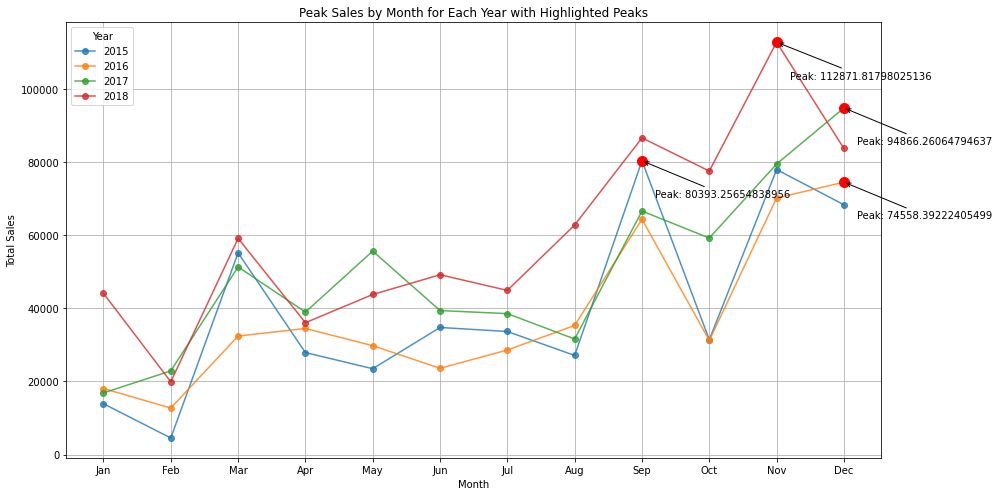

In [ ]:
# Create a line plot with all data points shown
plt.figure(figsize=(14, 7))
for year in monthly_sales['Year'].unique():
    yearly_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(yearly_data['Month'], yearly_data['Sales'], marker='o', label=year, alpha=0.8)

    # Highlight the peak sales
    peak_sales = yearly_data.loc[yearly_data['Sales'].idxmax()]
    plt.plot(peak_sales['Month'], peak_sales['Sales'], marker='o', markersize=10, color='red')  # Peak point
    plt.annotate(f'Peak: {peak_sales["Sales"]}',
                 xy=(peak_sales['Month'], peak_sales['Sales']),
                 xytext=(peak_sales['Month'] + 0.2, peak_sales['Sales'] - 10000),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.title('Peak Sales by Month for Each Year with Highlighted Peaks')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.grid()
plt.tight_layout()
plt.show()

**Notes:**
Inventory Management Recommendations
Based on the findings:

Increase Stock Levels: For months identified as peak months (e.g., November and December), increase stock levels in advance to meet expected demand.

Supplier Coordination: Work with suppliers to ensure timely delivery of products leading up to peak months.

Promotions and Marketing: Consider promotional campaigns during these peak months to maximize sales potential.

Seasonal Product Lines: Evaluate the introduction of seasonal products that align with peak months to leverage consumer demand.

**5.6 Which shipping modes are most popular among different customer segments?**




Steps of Analysis
    
    1. Group the dataset based on Segment and Ship_Mode columns and aggregate the sum of Sales.
    2. Normalize sales to calculate percentages within each segment.



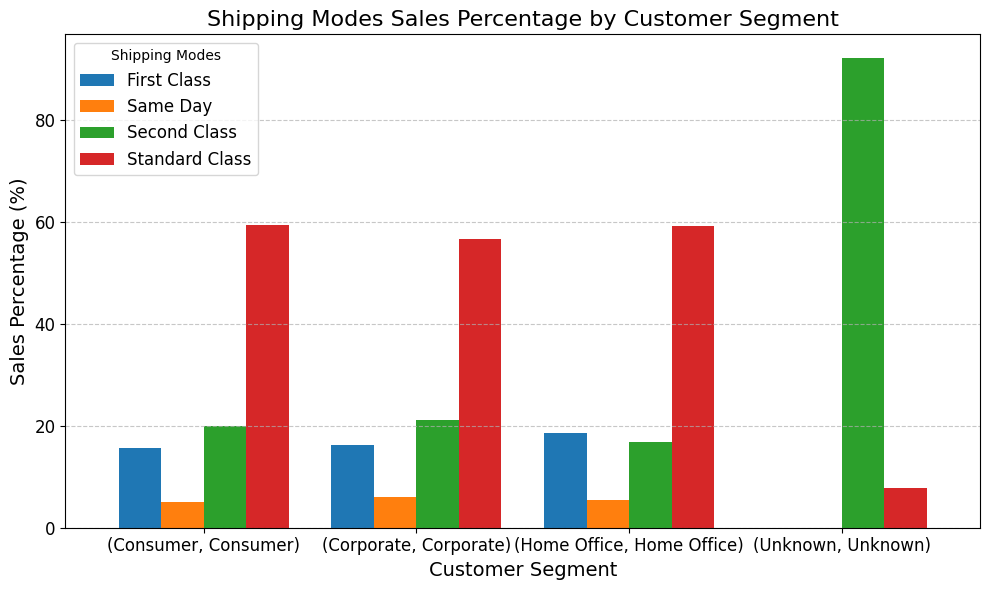

In [ ]:
shipping_segment_sales = ss.groupby(['Segment', 'Ship_Mode'])['Sales'].sum()
shipping_segment_percentage = shipping_segment_sales.groupby(level=0).apply(lambda x: 100 * x / x.sum()).unstack()
shipping_segment_percentage.plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('Shipping Modes Sales Percentage by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Sales Percentage (%)', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Shipping Modes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
shipping_segment_percentage

,Ship_Mode,First Class,Same Day,Second Class,Standard Class
Segment,Segment,,,,
Consumer,Consumer,15.654295,5.007745,19.896383,59.441577
Corporate,Corporate,16.310554,5.956390,21.094081,56.638975
Home Office,Home Office,18.529106,5.365785,16.876495,59.228615
Unknown,Unknown,NaN,NaN,92.137245,7.862755


The above graph clearly states that all the customers irrespective of the segement they belong to prioritize "Statndard Class" as their shipping mode. The least priority is given to the shipping mode "Same Day"

This could be due to the reason that the extra charge they have to pay for the faster delivery unless the delivery of the product is very urgent as we have seen i about 5 percent of the orders

**5.7 Are certain days of the week or times of day associated with higher sales volumes?**

Steps for Analysis

1. Ensure 'Order_Date' is in datetime format
2. Extract day of the week and hour from the 'Order_Date'
3. Group by Day of the Week and sum sales

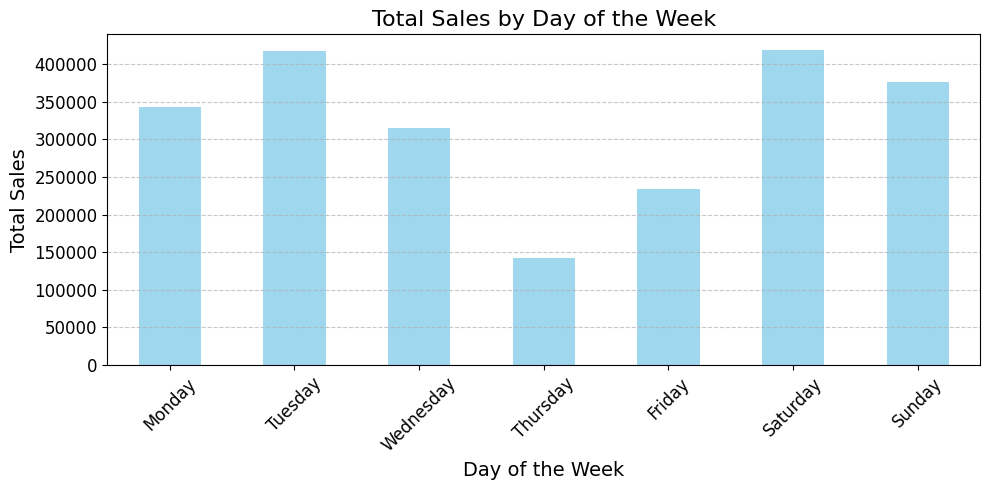

In [ ]:
ss['Order_Date'] = pd.to_datetime(ss['Order_Date'])
ss['Day_of_Week'] = ss['Order_Date'].dt.day_name()
sales_by_day = ss.groupby('Day_of_Week')['Sales'].sum()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = sales_by_day.reindex(days_order)

# Plot sales by day of the week
plt.figure(figsize=(10, 5))
sales_by_day.plot(kind='bar', color='skyblue', alpha=0.8)
plt.title('Total Sales by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




In [ ]:
sales_by_day

,Sales
Day_of_Week,
Monday,343140.314819
Tuesday,416999.143966
Wednesday,314553.848383
Thursday,142675.943674
Friday,234318.542867
Saturday,418647.793044
Sunday,375961.391931


Customers preferred to order the product equally on all the days except Thursday and Friday.This says that customers have very less tendency to place an order on Thursdays and Fridays. This could have been due to the several factors such as  promotional or marketing activity, customer behavior patterns, and operational constraints. By investigating these potential causes further, such as looking at past promotions or logistics patterns, businesses can make adjustments to ensure more consistent sales throughout the week.

**5.8 What are the top-selling product category within each region, and how can these insights be used to optimize inventory in different locations?**

Steps for Analysis

1. Group by Region and Category and sum the sales. Pivot the data to create a matrix where rows are regions and columns are categories

<Figure size 1200x800 with 0 Axes>

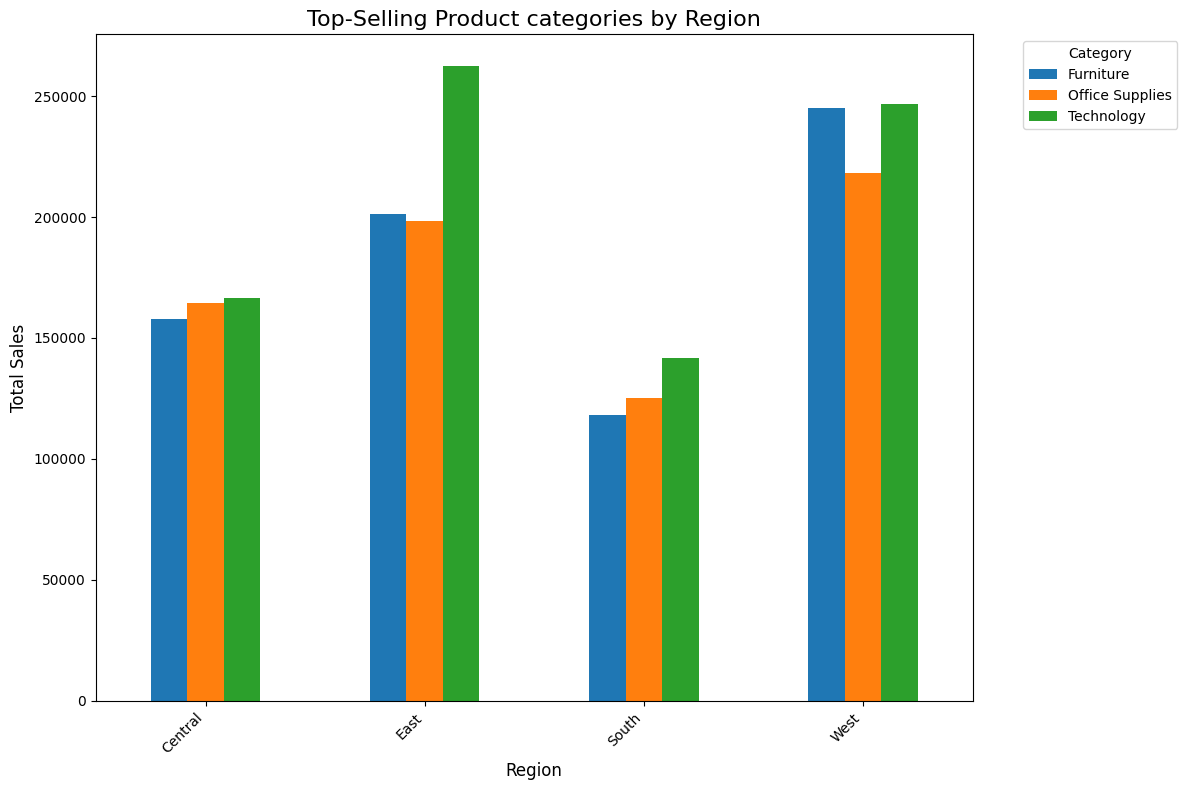

In [ ]:
region_category_sales = ss.groupby(['Region', 'Category'])['Sales'].sum().reset_index()
pivot_data = region_category_sales.pivot(index='Region', columns='Category', values='Sales')

plt.figure(figsize=(12, 8))

pivot_data.plot(kind='bar', stacked=False, figsize=(12, 8))

plt.title('Top-Selling Product categories by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
pivot_data

Category,Furniture,Office Supplies,Technology
Region,,,
Central,157710.956149,164479.938556,166689.203873
East,201338.939782,198464.197542,262376.112995
South,118256.659508,125063.459605,141585.400626
West,245220.051897,218325.816283,246786.241866


It has been clear that consumers have been purchasing more of technology items compared to others across all the regions except West where the category furniture has a slight lead in total number of sales over technology.

This could be due to the technological advancements that have been happening over the years. The variety .of products, customer dependency and the frequent discount programs could've also contributed to this purchasing patterns.

But still the purchasing of all the other category products is also significant. Consumers in genral are open to purchaase all types of products form this superstore.



**5.9 Analysis of Customer order frequency**

Steps for Analysis

1. Filter the customers who have more than one purchase
2. Find the percentage of repeat customers

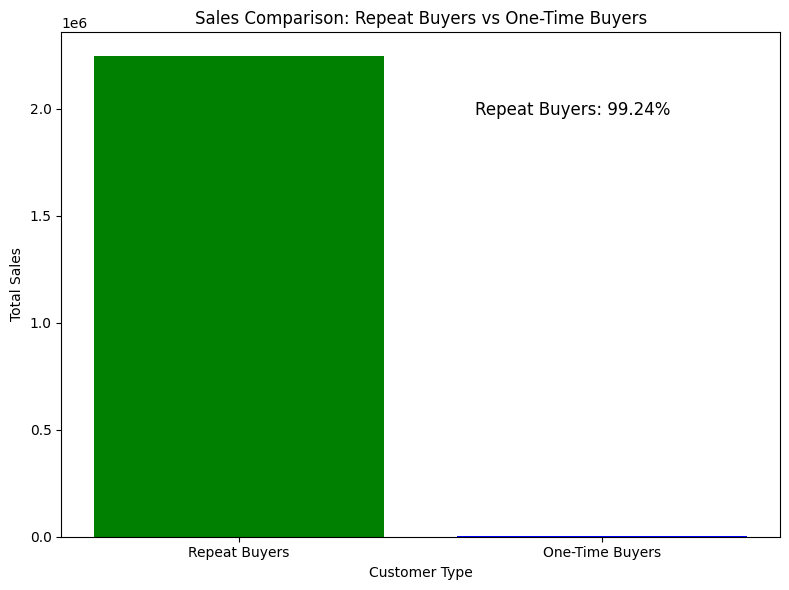

Percentage of Repeat Buyers: 99.24%
Total Sales from Repeat Buyers: $2,245,187.52
Total Sales from One-Time Buyers: $1,109.46


In [ ]:
customer_purchase_counts = ss['Customer_ID'].value_counts()
repeat_buyers = customer_purchase_counts[customer_purchase_counts > 1]
total_customers = len(customer_purchase_counts)

repeat_buyers_percentage = (len(repeat_buyers) / total_customers) * 100

repeat_buyers_sales = ss[ss['Customer_ID'].isin(repeat_buyers.index)]['Sales'].sum()
one_time_buyers_sales = ss[~ss['Customer_ID'].isin(repeat_buyers.index)]['Sales'].sum()

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(['Repeat Buyers', 'One-Time Buyers'], [repeat_buyers_sales, one_time_buyers_sales], color=['green', 'blue'])
ax.set_title('Sales Comparison: Repeat Buyers vs One-Time Buyers')
ax.set_ylabel('Total Sales')
ax.set_xlabel('Customer Type')

plt.figtext(0.6, 0.8, f'Repeat Buyers: {repeat_buyers_percentage:.2f}%', fontsize=12, ha='left')

plt.tight_layout()
plt.show()

print(f"Percentage of Repeat Buyers: {repeat_buyers_percentage:.2f}%")
print(f"Total Sales from Repeat Buyers: ${repeat_buyers_sales:,.2f}")
print(f"Total Sales from One-Time Buyers: ${one_time_buyers_sales:,.2f}")


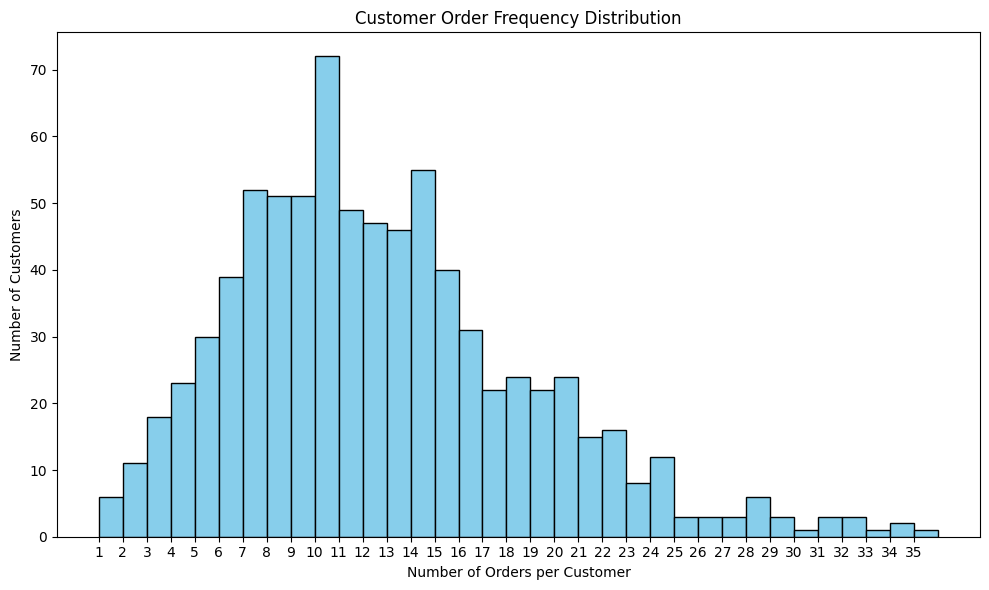

In [ ]:
customer_order_frequency = ss['Customer_ID'].value_counts()

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(customer_order_frequency, bins=range(1, customer_order_frequency.max()+2), edgecolor='black', color='skyblue')
plt.title('Customer Order Frequency Distribution')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')
plt.xticks(range(1, customer_order_frequency.max()+1))
plt.tight_layout()
plt.show()


In [ ]:
customer_order_frequency

,count
Customer_ID,
WB-21850,35
PP-18955,34
MA-17560,34
JL-15835,33
CK-12205,32
...,...
JR-15700,1
AO-10810,1
CJ-11875,1


Almost almost all the customers are repeated cutomers.

If almost all customers are repeat customers, it signifies strong customer loyalty and satisfaction, leading to several key benefits:

Customer Loyalty and Retention: High repeat purchase rates indicate trust and satisfaction, leading to brand loyalty and word-of-mouth marketing.

Cost Efficiency: Retaining existing customers is more cost-effective than acquiring new ones, reducing marketing costs and leveraging referrals.

Predictable Revenue: Repeat customers contribute to consistent sales, making it easier to manage inventory and forecast cash flow.

Increased Customer Lifetime Value (CLV): Repeat customers generally spend more over time, increasing their overall value to the business. Upselling and cross-selling opportunities are more viable.

Customer Feedback: Loyal customers provide valuable insights for product or service improvement, helping businesses innovate and grow.

**5.10 Analysis of segment and category of the product**

Steps for Analysis

1. Group by Segment and Category and sum the sales
2. Pivot the data for better visualization (rows are Segments, columns are Categories)

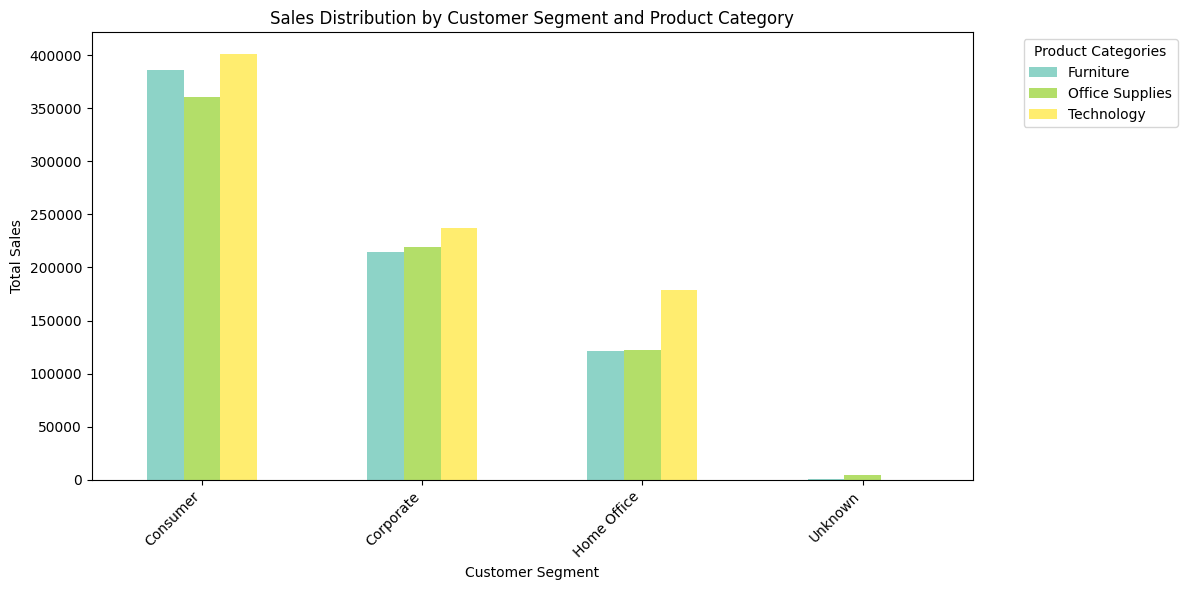

In [ ]:
segment_category_sales = ss.groupby(['Segment', 'Category'])['Sales'].sum().reset_index()
pivot = segment_category_sales.pivot(index='Segment', columns='Category', values='Sales')

pivot.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='Set3')

plt.title('Sales Distribution by Customer Segment and Product Category')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
pivot

Category,Furniture,Office Supplies,Technology
Segment,,,
Consumer,385920.038256,360174.784001,401310.253761
Corporate,214165.772270,219406.773092,237204.151989
Home Office,121118.444810,122053.230894,178893.563611
Unknown,1322.352000,4698.624000,28.990000


Simialr to the sales division by area, customers in each segement prioritize buying tecnological products it suggests that technology items are in high demand, driven by several factors:

Corporate Segment: Focuses on business technology (e.g., laptops, software).
Home Office Segment: Prioritizes productivity tech (e.g., video conferencing tools).
Consumer Segment: Prefers personal tech (e.g., smartphones, gaming systems).
Technological Dependence: All segments rely on technology for work, communication, and entertainment.

Marketing Influence: Targeted campaigns promote tech products, making them more desirable across segments.

Product Accessibility: Discounts, financing options, and innovation make tech products more accessible to all customers.